In [4]:
from google.colab import files

uploaded = files.upload()


Saving member5_linearsvc_results.csv to member5_linearsvc_results.csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Member 5's LinearSVC results
results = pd.read_csv("member5_linearsvc_results.csv")

# Display the results
results

,Model,Features,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,LinearSVC,40000,0.754375,0.315254,0.327465,0.321244,1114,202,191,93
1,LinearSVC (Balanced),40000,0.752500,0.313333,0.330986,0.321918,1110,206,190,94
2,LinearSVC,5000,0.736250,0.301724,0.369718,0.332278,1073,243,179,105
3,LinearSVC (Balanced),5000,0.732500,0.298883,0.376761,0.333333,1065,251,177,107
4,LinearSVC,1000,0.791875,0.351515,0.204225,0.258352,1209,107,226,58
5,LinearSVC (Balanced),1000,0.677500,0.281132,0.524648,0.366093,935,381,135,149


In [6]:
normal = results[results["Model"] == "LinearSVC"].copy()

balanced = results[results["Model"] == "LinearSVC (Balanced)"].copy()

normal

,Model,Features,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,LinearSVC,40000,0.754375,0.315254,0.327465,0.321244,1114,202,191,93
2,LinearSVC,5000,0.736250,0.301724,0.369718,0.332278,1073,243,179,105
4,LinearSVC,1000,0.791875,0.351515,0.204225,0.258352,1209,107,226,58


In [7]:
balanced

,Model,Features,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
1,LinearSVC (Balanced),40000,0.7525,0.313333,0.330986,0.321918,1110,206,190,94
3,LinearSVC (Balanced),5000,0.7325,0.298883,0.376761,0.333333,1065,251,177,107
5,LinearSVC (Balanced),1000,0.6775,0.281132,0.524648,0.366093,935,381,135,149


In [8]:
comparison = results[
    ["Model", "Features", "Accuracy", "Precision", "Recall", "F1", "TN", "FP", "FN", "TP"]
]

comparison

,Model,Features,Accuracy,Precision,Recall,F1,TN,FP,FN,TP
0,LinearSVC,40000,0.754375,0.315254,0.327465,0.321244,1114,202,191,93
1,LinearSVC (Balanced),40000,0.752500,0.313333,0.330986,0.321918,1110,206,190,94
2,LinearSVC,5000,0.736250,0.301724,0.369718,0.332278,1073,243,179,105
3,LinearSVC (Balanced),5000,0.732500,0.298883,0.376761,0.333333,1065,251,177,107
4,LinearSVC,1000,0.791875,0.351515,0.204225,0.258352,1209,107,226,58
5,LinearSVC (Balanced),1000,0.677500,0.281132,0.524648,0.366093,935,381,135,149


In [9]:
# Match normal and balanced models by feature count
normal_indexed = normal.set_index("Features")
balanced_indexed = balanced.set_index("Features")

comparison_change = pd.DataFrame({
    "Normal Recall": normal_indexed["Recall"],
    "Balanced Recall": balanced_indexed["Recall"],
    "Recall Change": balanced_indexed["Recall"] - normal_indexed["Recall"],

    "Normal Precision": normal_indexed["Precision"],
    "Balanced Precision": balanced_indexed["Precision"],
    "Precision Change": balanced_indexed["Precision"] - normal_indexed["Precision"],

    "Normal F1": normal_indexed["F1"],
    "Balanced F1": balanced_indexed["F1"],
    "F1 Change": balanced_indexed["F1"] - normal_indexed["F1"],

    "Normal FN": normal_indexed["FN"],
    "Balanced FN": balanced_indexed["FN"],
    "FN Change": balanced_indexed["FN"] - normal_indexed["FN"],

    "Normal FP": normal_indexed["FP"],
    "Balanced FP": balanced_indexed["FP"],
    "FP Change": balanced_indexed["FP"] - normal_indexed["FP"]
})

comparison_change

,Normal Recall,Balanced Recall,Recall Change,Normal Precision,Balanced Precision,Precision Change,Normal F1,Balanced F1,F1 Change,Normal FN,Balanced FN,FN Change,Normal FP,Balanced FP,FP Change
Features,,,,,,,,,,,,,,,
40000,0.327465,0.330986,0.003521,0.315254,0.313333,-0.001921,0.321244,0.321918,0.000674,191,190,-1,202,206,4
5000,0.369718,0.376761,0.007042,0.301724,0.298883,-0.002841,0.332278,0.333333,0.001055,179,177,-2,243,251,8
1000,0.204225,0.524648,0.320423,0.351515,0.281132,-0.070383,0.258352,0.366093,0.107741,226,135,-91,107,381,274


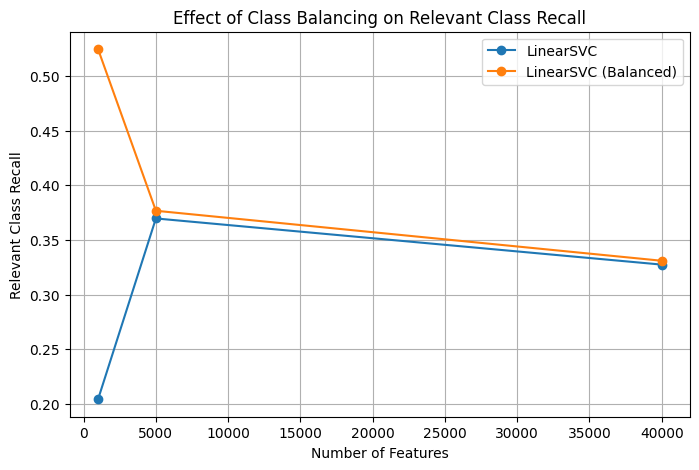

In [12]:
normal_plot = normal.sort_values("Features")
balanced_plot = balanced.sort_values("Features")

plt.figure(figsize=(8, 5))

plt.plot(
    normal_plot["Features"],
    normal_plot["Recall"],
    marker="o",
    label="LinearSVC"
)

plt.plot(
    balanced_plot["Features"],
    balanced_plot["Recall"],
    marker="o",
    label="LinearSVC (Balanced)"
)

plt.xlabel("Number of Features")
plt.ylabel("Relevant Class Recall")
plt.title("Effect of Class Balancing on Relevant Class Recall")
plt.legend()
plt.grid(True)

plt.show()

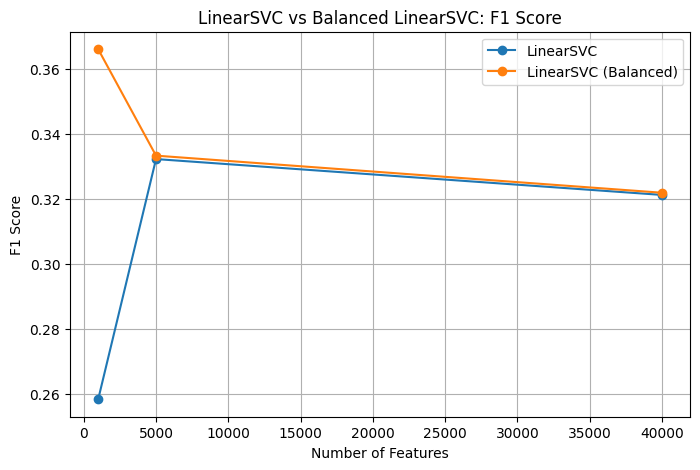

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    normal_plot["Features"],
    normal_plot["F1"],
    marker="o",
    label="LinearSVC"
)

plt.plot(
    balanced_plot["Features"],
    balanced_plot["F1"],
    marker="o",
    label="LinearSVC (Balanced)"
)

plt.xlabel("Number of Features")
plt.ylabel("F1 Score")
plt.title("LinearSVC vs Balanced LinearSVC: F1 Score")
plt.legend()
plt.grid(True)

plt.show()